In [1]:
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import ttest_ind
from scipy.interpolate import interp1d, barycentric_interpolate

import pandas as pd

from neurodsp import sim
from neurodsp.spectral import compute_spectrum

from fooof import FOOOF
from fooof.core.funcs import expo_const_function, expo_double_const_function
from timescales.fit import PSD
from timescales.plts import set_default_rc
from ad_organoids.spectral import compute_spectra_windows

from sklearn.svm import SVC
from sklearn.preprocessing import normalize

set_default_rc()

# Classifying Oscillations

This notebooks explores using simulation + SVM to predict time windows with oscillations. The training set is formed using simulations of aperiodic spectra with and without oscillatons. Simualted periodic and aperiodic parameters are randomize. A SVM is trained on the simulated data, and subsequently applied to organoid LFP data.

In [2]:
# Settings
fs = 2000
n_seconds = 10
freq = 10
niters = 5000

# Aperiodic
ap_types = ['knee', '1/f']

exps = np.linspace(-4, 0, 101)
exps = np.random.choice(exps, size=niters)

ap_type = [0, 1]
ap_types = np.random.choice(ap_type, size=niters)

knees = np.arange(30, 101)
knees = np.random.choice(knees, size=niters)

# Periodic
freqs_osc = np.arange(30, 101)
freqs_osc = np.random.choice(freqs_osc, size=niters)

cyc_types = ['sine', 'asine', 'sawtooth']
cyc_types = np.random.choice(cyc_types, size=niters)

rdsym = np.linspace(0, 1, 101)
rdsym = np.random.choice(rdsym, size=niters)

width = np.linspace(0, 1, 101)
width = np.random.choice(rdsym, size=niters)

variances = np.linspace(.99, 1, 21)
variances = np.random.choice(variances, size=niters)

# Get output shape and intialize array
freqs, powers = compute_spectrum(np.ones(int(fs * n_seconds)), fs)
inds = np.where((freqs >= 30) & (freqs <= 100))[0]

freqs = freqs[inds]
powers = np.zeros((2, niters, len(powers[inds])))

In [3]:
for i in tqdm(range(niters), total=niters):
    
    np.random.seed(i)
    
    # Variance
    ap_var = variances[i]
    pe_var = 1 - ap_var
    
    # Aperiodic
    
    # Knee simulations are too slow
    #if ap_types[i] == 0:
    #    sig_ap = sim.aperiodic.sim_knee(n_seconds, fs, 0, exps[i], knees[i], variance=ap_var)
    #else:
    
    sig_ap = sim.aperiodic.sim_powerlaw(n_seconds, fs, exps[i], mean=0, variance=ap_var)
                
    # Periodic
    params = {}
    
    if cyc_types[i] == 'asine':
        params = {'rdsym': rdsym[i]}
    elif cyc_types[i] =='sawtooth':
        params = {'width': width[i]}
        
    sig_pe = sim.periodic.sim_oscillation(n_seconds, fs, freqs_osc[i], cycle=cyc_types[i], mean=0, variance=pe_var, **params)
    
    # Combine
    sig = sig_ap + sig_pe
    
    # PSD
    _, _powers = compute_spectrum(sig_ap, fs)
    powers[0, i] = _powers[inds]
    
    _, _powers = compute_spectrum(sig, fs)
    powers[1, i] = _powers[inds]

  0%|          | 0/5000 [00:00<?, ?it/s]

# Train SVM
To predict oscillations.

In [5]:
n_freqs = powers.shape[-1]

labels = np.ones(niters*2)
labels[:len(labels)//2] = 0

clf = SVC(gamma='auto')
clf = clf.fit(normalize(powers.reshape(-1, n_freqs)), labels)

# Predict Organoid LFP

In [6]:
# Paths
dirpath = '/home/rphammonds/projects/ad_organoids'
meta_path = f'{dirpath}/data/plate4/meta.json'
spectra_path = f'{dirpath}/spectra/plate4/plate4_midpoint_00/welch'

# Load meta data
with open(meta_path) as json_file:
    meta = json.load(json_file)
    
# Unpack dict
fs = meta['fs'] * 1000
scale = meta['scale']
wells = np.array(meta['well_labels'])

# Load freqs and powers
_freqs = np.load(f"{spectra_path}/freqs.npz")['arr_0']
_powers = np.load(f"{spectra_path}/powers.npz")['arr_0']

# Reshape to 2d
orig_shape = _powers.shape
powers_real = _powers.reshape(-1, orig_shape[-1])

In [7]:
# Predict oscillatory windows using trained SVM
labels_predict = clf.predict(normalize(powers_real[:, inds]))

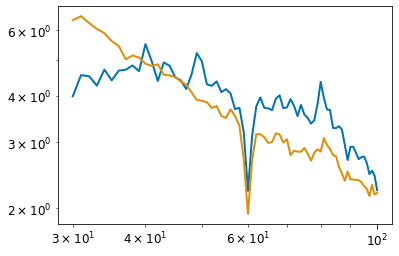

In [9]:
plt.loglog(_freqs[inds], powers_real[np.where(labels_predict == 1)[0]].mean(axis=0)[inds])

plt.loglog(_freqs[inds], powers_real[np.where(labels_predict == 0)[0]].mean(axis=0)[inds])

In [10]:
# Oscillations
powers_real[np.where(labels_predict == 1)[0]].shape

(401, 1001)

In [11]:
# Non-oscillations
powers_real[np.where(labels_predict == 0)[0]].shape

(2431, 1001)